# Regression Models

The objective of this section is to predict the Democratic vote share in the 2024 U.S. Presidential Election at the county level. Unlike the classification models, which predict the winning party, regression models estimate the proportion of votes received by the Democratic candidate in each county.

Several regression algorithms are evaluated and compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [3]:
import pandas as pd

df = pd.read_csv(
    "..\\data\\processed\\historical_model_ready_dataset.csv"
)

print(df.shape)
df.head()

(3063, 202)


,GEO_ID,NAME,county_fips,B01001_001E,B01001_002E,B01001_003E,B01001_004E,B01001_005E,B01001_006E,B01001_007E,...,winner_2016,winner_2020,avg_dem_share_2000_2020,dem_wins_count_2000_2020,vote_volatility_2000_2020,swing_2016_2020,swing_2012_2020,swing_2000_2020,target_2024_party_winner,target_2024_dem_vote_share
0,0500000US01001,"Autauga County, Alabama",1001,55639,27052,1727,2156,1674,1208,553,...,0.0,0.0,0.259270,0.0,0.019539,0.032487,0.004305,-0.017008,0.0,0.263039
1,0500000US01003,"Baldwin County, Alabama",1003,218289,105889,6082,5197,8289,4305,2406,...,0.0,0.0,0.224135,0.0,0.018666,0.030234,0.008196,-0.023732,0.0,0.203961
2,0500000US01005,"Barbour County, Alabama",1005,25026,13156,660,741,721,467,261,...,0.0,0.0,0.479025,2.0,0.025680,-0.007397,-0.055803,-0.041204,0.0,0.421918
3,0500000US01007,"Bibb County, Alabama",1007,22374,12022,626,693,621,569,323,...,0.0,0.0,0.267245,0.0,0.062940,-0.005513,-0.054537,-0.174654,0.0,0.174895
4,0500000US01009,"Blount County, Alabama",1009,57755,28677,1844,1738,2034,1257,743,...,0.0,0.0,0.151475,0.0,0.070961,0.011436,-0.028025,-0.181222,0.0,0.091468


In [8]:
target_column = "target_2024_dem_vote_share"

leakage_columns = [
    "GEO_ID",
    "NAME",
    "county_fips",
    "state",
    "county_name",

    "party_winner",
    "dem_vote_share",
    "democrat_votes",
    "republican_votes",
    "totalvotes",

    "target_2024_party_winner",
    "target_2024_dem_vote_share"
]

X = df.drop(columns=leakage_columns, errors="ignore")
y = df[target_column]

# keep only numeric columns
X = X.select_dtypes(include=["int64", "float64"])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Non-numeric columns remaining:", X.select_dtypes(exclude=["int64", "float64"]).columns.tolist())

Feature matrix shape: (3063, 190)
Target shape: (3063,)
Non-numeric columns remaining: []


## Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Scaling complete.")

Train shape: (2450, 190)
Test shape: (613, 190)
Scaling complete.


# Linear Regression

Linear Regression is used as a baseline regression model for predicting the Democratic vote share in the 2024 election. The model assumes a linear relationship between the input features and the target variable and provides an interpretable benchmark against which more complex regression models can be compared.

## Train Linear Regression Model

In [13]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

print("Linear Regression model training complete.")

Linear Regression model training complete.


## Generate Predictions

In [14]:
y_pred_linear = linear_model.predict(X_test_scaled)

## Evaluate Model Performance

In [15]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = mean_squared_error(
    y_test,
    y_pred_linear
) ** 0.5

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("LINEAR REGRESSION RESULTS")
print("=" * 50)

print(f"MAE: {mae_linear:.4f}")
print(f"RMSE: {rmse_linear:.4f}")
print(f"R² Score: {r2_linear:.4f}")

LINEAR REGRESSION RESULTS
MAE: 0.0723
RMSE: 0.1015
R² Score: 0.7008


## Actual vs Predicted Values

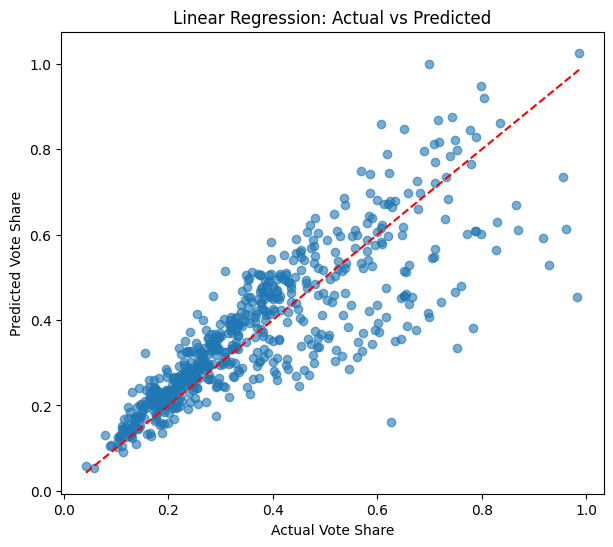

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Vote Share")

plt.ylabel("Predicted Vote Share")

plt.title("Linear Regression: Actual vs Predicted")

plt.show()

## Residual Analysis

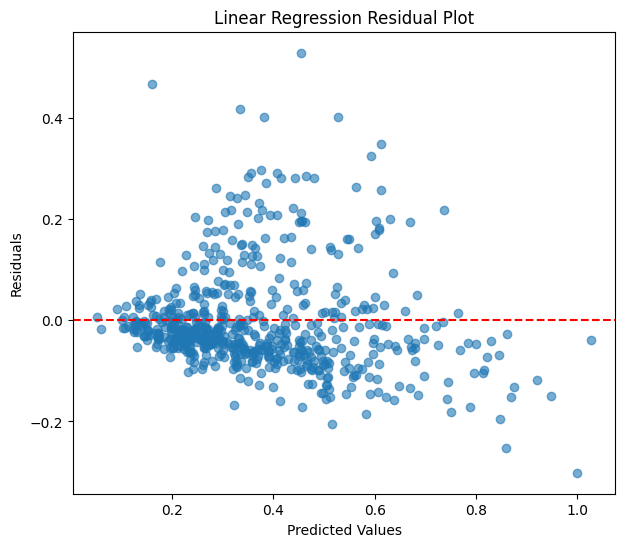

In [17]:
residuals = y_test - y_pred_linear

plt.figure(figsize=(7,6))

plt.scatter(
    y_pred_linear,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Linear Regression Residual Plot")

plt.show()

## Most Influential Features

In [18]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

display(coefficients.head(20))

,Feature,Coefficient,Absolute_Coefficient
150,B23025_007E,-8.770379,8.770379
144,B23025_001E,-5.577181,5.577181
147,B23025_004E,-4.120489,4.120489
146,B23025_003E,-3.885405,3.885405
145,B23025_002E,-3.872358,3.872358
155,labor_force,-3.872358,3.872358
141,B17001_057E,3.834147,3.834147
140,B17001_056E,3.406784,3.406784
139,B17001_055E,-2.131538,2.131538
36,B01001_037E,2.081346,2.081346


# Ridge Regression

Ridge Regression is an extension of Linear Regression that adds L2 regularization to reduce the impact of multicollinearity and prevent overfitting. By penalizing large coefficient values, Ridge Regression often produces more stable and generalizable predictions when dealing with datasets containing many correlated features.

## Train Ridge Regression Model

In [19]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

print("Ridge Regression model training complete.")

Ridge Regression model training complete.


## Generate Predictions

In [20]:
y_pred_ridge = ridge_model.predict(X_test_scaled)

## Evaluate Model Performance

In [21]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

rmse_ridge = mean_squared_error(
    y_test,
    y_pred_ridge
) ** 0.5

r2_ridge = r2_score(
    y_test,
    y_pred_ridge
)

print("RIDGE REGRESSION RESULTS")
print("=" * 50)

print(f"MAE: {mae_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"R² Score: {r2_ridge:.4f}")

RIDGE REGRESSION RESULTS
MAE: 0.0703
RMSE: 0.0987
R² Score: 0.7171


## Actual vs Predicted Values

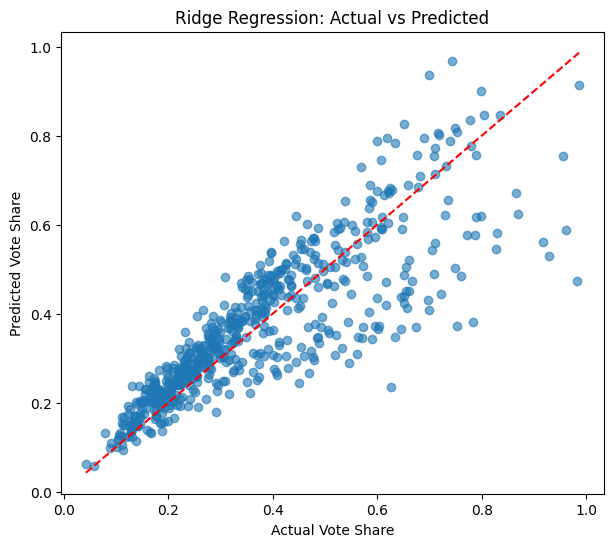

In [22]:
plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    y_pred_ridge,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Vote Share")
plt.ylabel("Predicted Vote Share")

plt.title("Ridge Regression: Actual vs Predicted")

plt.show()

## Residual Analysis

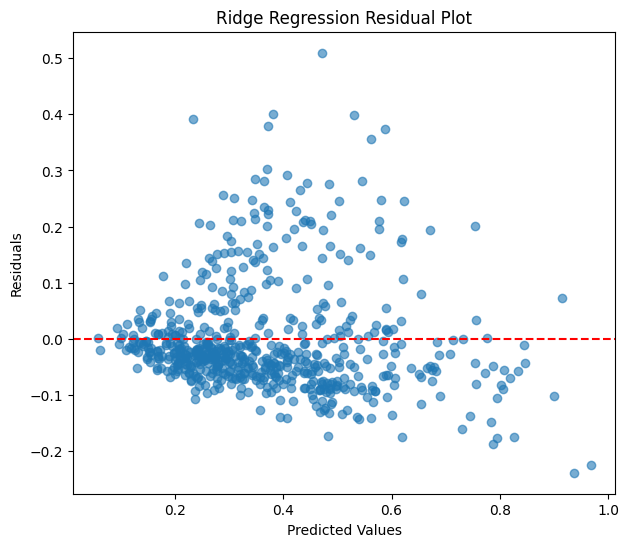

In [23]:
residuals_ridge = y_test - y_pred_ridge

plt.figure(figsize=(7,6))

plt.scatter(
    y_pred_ridge,
    residuals_ridge,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Ridge Regression Residual Plot")

plt.show()

## Most Influential Features

In [24]:
ridge_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_model.coef_
})

ridge_coefficients["Absolute_Coefficient"] = (
    ridge_coefficients["Coefficient"].abs()
)

ridge_coefficients = ridge_coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

display(ridge_coefficients.head(20))

,Feature,Coefficient,Absolute_Coefficient
46,B01001_047E,0.122691,0.122691
133,B17001_049E,0.111096,0.111096
77,B15003_019E,-0.106896,0.106896
137,B17001_053E,-0.103648,0.103648
6,B01001_007E,0.099841,0.099841
65,B15003_007E,0.087028,0.087028
40,B01001_041E,-0.085640,0.085640
109,B17001_025E,0.079475,0.079475
39,B01001_040E,-0.079057,0.079057
74,B15003_016E,-0.076016,0.076016


# Lasso Regression

Lasso Regression extends Linear Regression by applying L1 regularization. Unlike Ridge Regression, Lasso can shrink some coefficients completely to zero, effectively performing automatic feature selection. This makes Lasso particularly useful for identifying the most important predictors while reducing model complexity.

## Train Lasso Regression Model

In [25]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(
    alpha=0.001,
    random_state=42,
    max_iter=10000
)

lasso_model.fit(
    X_train_scaled,
    y_train
)

print("Lasso Regression model training complete.")

Lasso Regression model training complete.


## Generate Predictions

In [26]:
y_pred_lasso = lasso_model.predict(X_test_scaled)

## Evaluate Model Performance

In [27]:
mae_lasso = mean_absolute_error(
    y_test,
    y_pred_lasso
)

rmse_lasso = mean_squared_error(
    y_test,
    y_pred_lasso
) ** 0.5

r2_lasso = r2_score(
    y_test,
    y_pred_lasso
)

print("LASSO REGRESSION RESULTS")
print("=" * 50)

print(f"MAE: {mae_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.4f}")
print(f"R² Score: {r2_lasso:.4f}")

LASSO REGRESSION RESULTS
MAE: 0.0698
RMSE: 0.0987
R² Score: 0.7172


## Actual vs Predicted Values

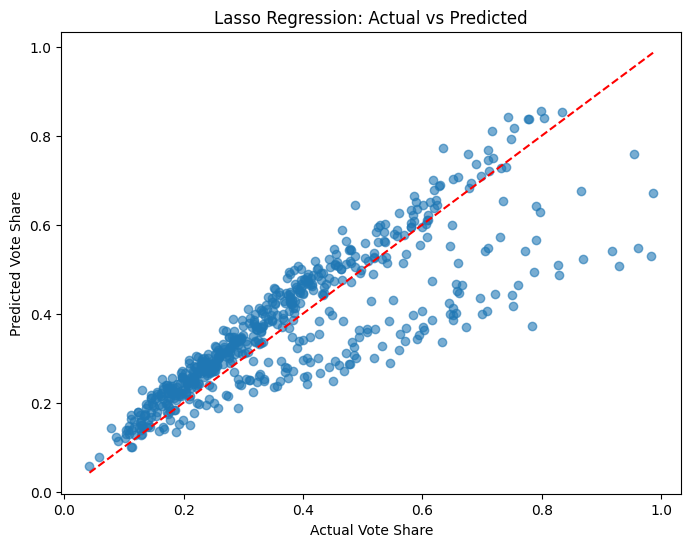

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_lasso,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Vote Share")
plt.ylabel("Predicted Vote Share")

plt.title("Lasso Regression: Actual vs Predicted")

plt.show()

## Residual Analysis

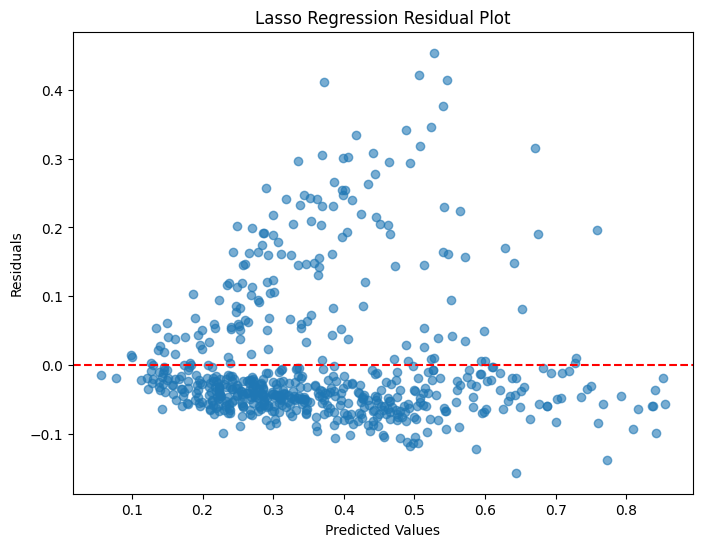

In [29]:
residuals_lasso = y_test - y_pred_lasso

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_lasso,
    residuals_lasso,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Lasso Regression Residual Plot")

plt.show()

## Most Influential Features

In [30]:
lasso_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_model.coef_
})

lasso_coefficients["Absolute_Coefficient"] = (
    lasso_coefficients["Coefficient"].abs()
)

lasso_coefficients = lasso_coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

display(lasso_coefficients.head(20))

,Feature,Coefficient,Absolute_Coefficient
176,dem_share_2016,0.130543,0.130543
71,B15003_013E,0.019475,0.019475
168,white_pct,-0.018169,0.018169
169,black_pct,-0.016313,0.016313
74,B15003_016E,-0.016130,0.016130
171,log_population,0.015864,0.015864
114,B17001_030E,-0.015344,0.015344
173,dem_share_2004,0.013200,0.013200
188,swing_2012_2020,0.011984,0.011984
183,winner_2020,-0.010600,0.010600


## Feature Selection Summary

In [31]:
selected_features = (
    lasso_model.coef_ != 0
).sum()

removed_features = (
    lasso_model.coef_ == 0
).sum()

print("Total Features:", len(lasso_model.coef_))
print("Selected Features:", selected_features)
print("Removed Features:", removed_features)

Total Features: 190
Selected Features: 28
Removed Features: 162


# Random Forest Regressor

Random Forest Regressor is an ensemble learning method that combines multiple decision trees to improve predictive performance and reduce overfitting. By averaging predictions across many trees, Random Forest can capture complex non-linear relationships between demographic characteristics, historical election trends, and county-level vote share outcomes.

## Train Random Forest Regressor

In [33]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_regressor.fit(
    X_train,
    y_train
)

print("Random Forest Regressor training complete.")

Random Forest Regressor training complete.


## Generate Predictions

In [34]:
y_pred_rf_reg = rf_regressor.predict(X_test)

## Evaluate Model Performance

In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_rf_reg = mean_absolute_error(
    y_test,
    y_pred_rf_reg
)

rmse_rf_reg = mean_squared_error(
    y_test,
    y_pred_rf_reg
) ** 0.5

r2_rf_reg = r2_score(
    y_test,
    y_pred_rf_reg
)

print("RANDOM FOREST REGRESSOR RESULTS")
print("=" * 50)

print(f"MAE: {mae_rf_reg:.4f}")
print(f"RMSE: {rmse_rf_reg:.4f}")
print(f"R² Score: {r2_rf_reg:.4f}")

RANDOM FOREST REGRESSOR RESULTS
MAE: 0.0638
RMSE: 0.0930
R² Score: 0.7491


## Actual vs Predicted Values

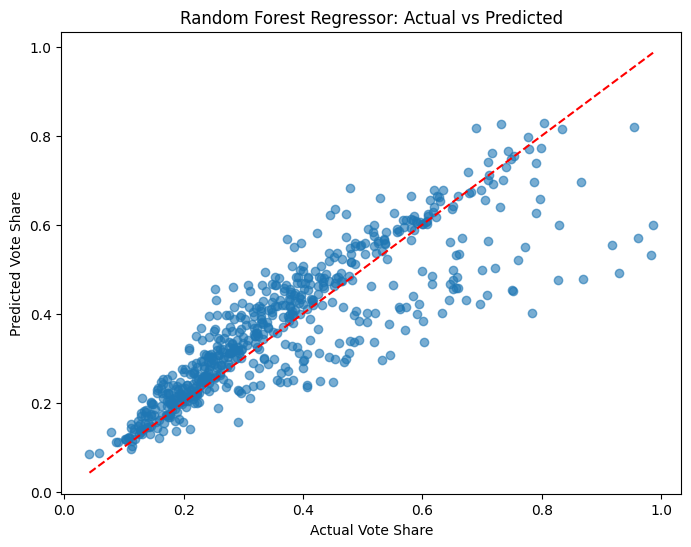

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf_reg,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Vote Share")
plt.ylabel("Predicted Vote Share")

plt.title("Random Forest Regressor: Actual vs Predicted")

plt.show()

## Residual Analysis

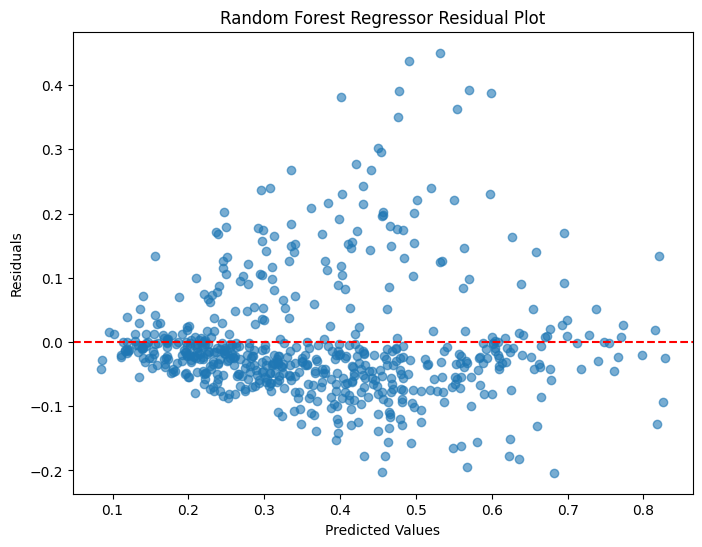

In [37]:
residuals_rf_reg = y_test - y_pred_rf_reg

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_rf_reg,
    residuals_rf_reg,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Random Forest Regressor Residual Plot")

plt.show()

## Feature Importance Analysis

In [38]:
feature_importance_rf_reg = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_regressor.feature_importances_
})

feature_importance_rf_reg = feature_importance_rf_reg.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance_rf_reg.head(20))

,Feature,Importance
176,dem_share_2016,0.534068
177,dem_share_2020,0.179058
184,avg_dem_share_2000_2020,0.016988
52,B02001_004E,0.013185
168,white_pct,0.010016
187,swing_2016_2020,0.009454
174,dem_share_2008,0.009230
56,B02001_008E,0.009200
55,B02001_007E,0.006685
189,swing_2000_2020,0.006664


## Top 20 Feature Importance Visualization

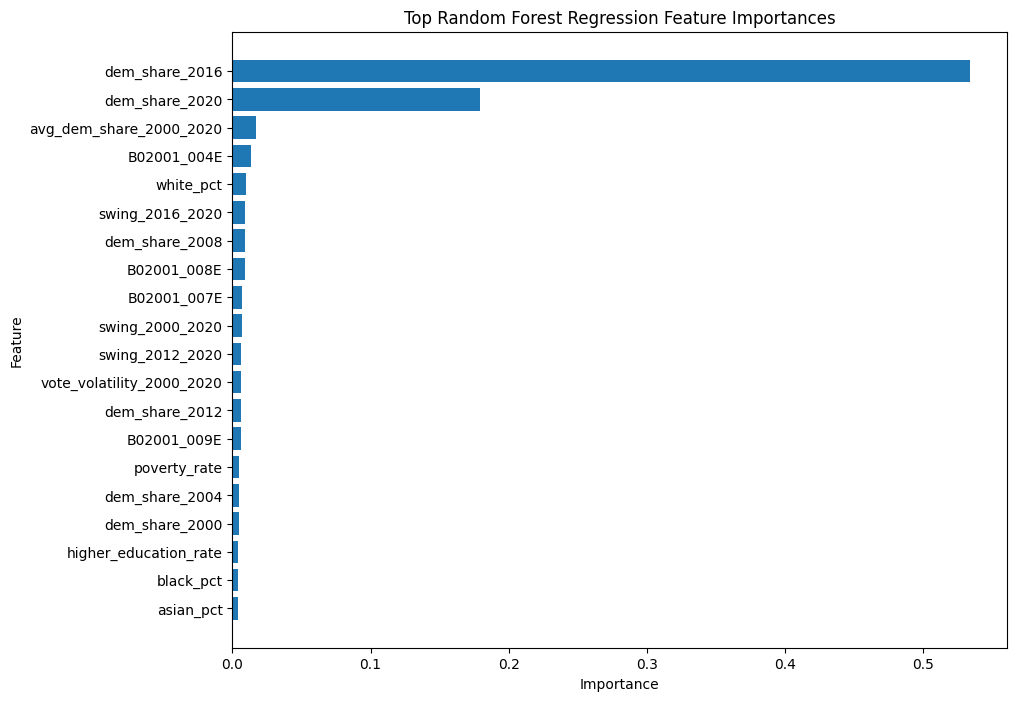

In [39]:
top_features_rf_reg = (
    feature_importance_rf_reg
    .head(20)
    .sort_values(by="Importance")
)

plt.figure(figsize=(10,8))

plt.barh(
    top_features_rf_reg["Feature"],
    top_features_rf_reg["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top Random Forest Regression Feature Importances")

plt.show()

# XGBoost Regressor

XGBoost Regressor is a gradient boosting algorithm that builds trees sequentially, with each new tree correcting errors made by previous trees. It is one of the most powerful machine learning algorithms for structured tabular data and is widely used in predictive modeling competitions and real-world forecasting applications.

## Train XGBoost Regressor

In [40]:
from xgboost import XGBRegressor

xgb_regressor = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_regressor.fit(
    X_train,
    y_train
)

print("XGBoost Regressor training complete.")

XGBoost Regressor training complete.


## Generate Predictions

In [41]:
y_pred_xgb_reg = xgb_regressor.predict(X_test)

## Evaluate Model Performance

In [42]:
mae_xgb_reg = mean_absolute_error(
    y_test,
    y_pred_xgb_reg
)

rmse_xgb_reg = mean_squared_error(
    y_test,
    y_pred_xgb_reg
) ** 0.5

r2_xgb_reg = r2_score(
    y_test,
    y_pred_xgb_reg
)

print("XGBOOST REGRESSOR RESULTS")
print("=" * 50)

print(f"MAE: {mae_xgb_reg:.4f}")
print(f"RMSE: {rmse_xgb_reg:.4f}")
print(f"R² Score: {r2_xgb_reg:.4f}")

XGBOOST REGRESSOR RESULTS
MAE: 0.0590
RMSE: 0.0879
R² Score: 0.7760


## Actual vs Predicted Values

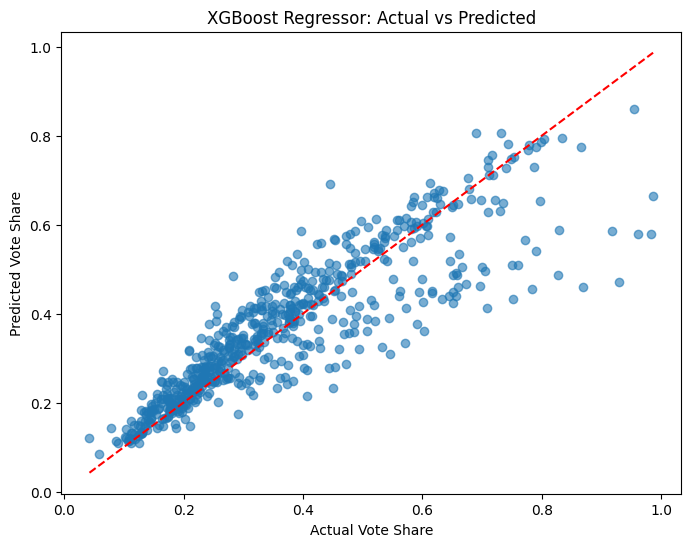

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_xgb_reg,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Vote Share")
plt.ylabel("Predicted Vote Share")

plt.title("XGBoost Regressor: Actual vs Predicted")

plt.show()

## Residual Analysis

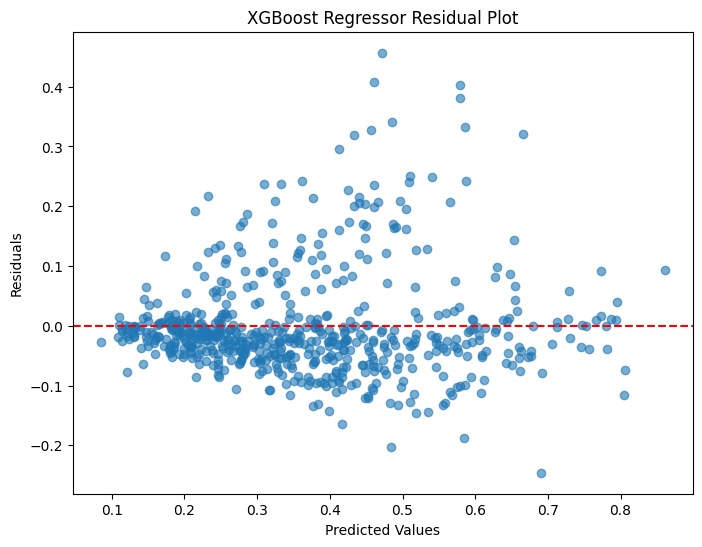

In [44]:
residuals_xgb_reg = y_test - y_pred_xgb_reg

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_xgb_reg,
    residuals_xgb_reg,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("XGBoost Regressor Residual Plot")

plt.show()

## Feature Importance Analysis

In [45]:
feature_importance_xgb_reg = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_regressor.feature_importances_
})

feature_importance_xgb_reg = (
    feature_importance_xgb_reg
    .sort_values(
        by="Importance",
        ascending=False
    )
)

display(feature_importance_xgb_reg.head(20))

,Feature,Importance
176,dem_share_2016,0.215416
177,dem_share_2020,0.080625
185,dem_wins_count_2000_2020,0.027579
184,avg_dem_share_2000_2020,0.013572
180,winner_2008,0.012878
145,B23025_002E,0.011944
56,B02001_008E,0.010557
158,bachelors_degree,0.009426
156,unemployed,0.008655
133,B17001_049E,0.008625


## Top 20 Feature Importance Visualization

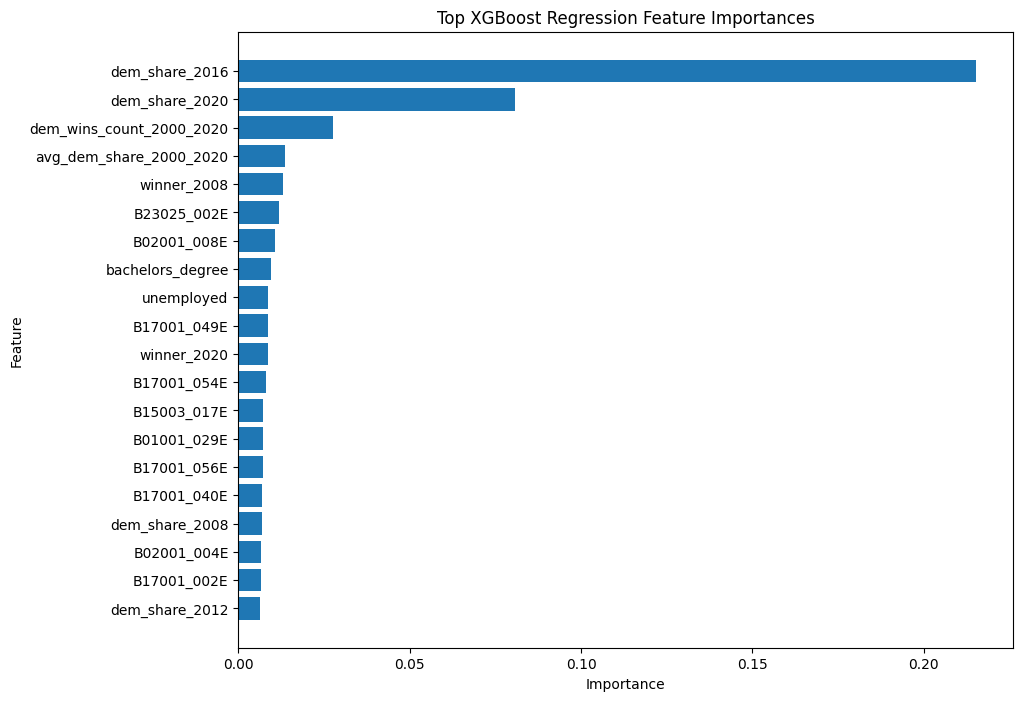

In [46]:
top_features_xgb_reg = (
    feature_importance_xgb_reg
    .head(20)
    .sort_values(by="Importance")
)

plt.figure(figsize=(10,8))

plt.barh(
    top_features_xgb_reg["Feature"],
    top_features_xgb_reg["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top XGBoost Regression Feature Importances")

plt.show()

# Regression Model Comparison

In [47]:
regression_results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest Regressor",
        "XGBoost Regressor"
    ],

    "MAE": [
        mae_linear,
        mae_ridge,
        mae_lasso,
        mae_rf_reg,
        mae_xgb_reg
    ],

    "RMSE": [
        rmse_linear,
        rmse_ridge,
        rmse_lasso,
        rmse_rf_reg,
        rmse_xgb_reg
    ],

    "R2": [
        r2_linear,
        r2_ridge,
        r2_lasso,
        r2_rf_reg,
        r2_xgb_reg
    ]
})

regression_results = regression_results.sort_values(
    by="R2",
    ascending=False
)

display(regression_results)

regression_results.to_csv(
    "regression_model_comparison.csv",
    index=False
)

,Model,MAE,RMSE,R2
4,XGBoost Regressor,0.059044,0.087851,0.775954
3,Random Forest Regressor,0.063783,0.092965,0.749113
2,Lasso Regression,0.069767,0.098709,0.717150
1,Ridge Regression,0.070328,0.098717,0.717104
0,Linear Regression,0.072330,0.101520,0.700813
